Αντιγόνη Στεφάνου

1115202000281 (sdi2000281)

In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING']="1"
os.environ['TORCH_USE_CUDA_DSA'] = "1"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
# !unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/
from nltk.stem import WordNetLemmatizer
import emoji
import gensim.downloader
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, \
                            ConfusionMatrixDisplay, roc_auc_score, roc_curve, \
                            precision_score, recall_score

Load the datasets

In [3]:
# train = pd.read_csv(r'train_dataset.csv')
# val = pd.read_csv(r'val_dataset.csv')
# test = pd.read_csv(r'test_dataset.csv')

train = pd.read_csv(r'/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/train_dataset.csv')
val = pd.read_csv(r'/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/val_dataset.csv')
test = pd.read_csv(r'/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/test_dataset.csv')

### Word Embeddings

Use word vectors pre-trained on Twitter data

In [4]:
# !wget http://nlp.stanford.edu/data/glove.twitter.27B.zip
# !unzip glove*.zip

# glove_input_file = 'glove.twitter.27B/glove.twitter.27B.200d.txt'
# w2v_output_file = 'glove.twitter.27B/glv200_with_w2v_format.txt'
# glove2word2vec(glove_input_file, w2v_output_file) #convert GloVe vectors into the word2vec
# w2v = KeyedVectors.load_word2vec_format('glove.twitter.27B/glv200_with_w2v_format.txt', binary=False)

w2v = gensim.downloader.load('glove-twitter-200')

[==================================================] 100.0% 758.5/758.5MB downloaded


### Text Preprocessing

In [5]:
# Store the clean datasets in different variables so we don't mess with the initial data
train_clean = train.copy()
val_clean = val.copy()
test_clean = test.copy()

Replace emojis with their respective descriptive word/phrase

In [6]:
train_clean['Text'] = train_clean.Text.apply(emoji.demojize)
val_clean['Text'] = val_clean.Text.apply(emoji.demojize)
test_clean['Text'] = test_clean.Text.apply(emoji.demojize)

Remove all HTML reference characters

In [7]:
train_clean.Text = train_clean.Text.apply(lambda x: re.sub(r'&[a-z]+;', ' ', x))
val_clean.Text = val_clean.Text.apply(lambda x: re.sub(r'&[a-z]+;', ' ', x))
test_clean.Text = test_clean.Text.apply(lambda x: re.sub(r'&[a-z]+;', ' ', x))

Replace all phone numbers with '\<number>\'

In [8]:
train_clean.Text = train_clean.Text.apply(lambda x: re.sub(r'[-+]?[.\d]*[\d]+[:,.\d]*', ' <number> ', x))
val_clean.Text = val_clean.Text.apply(lambda x: re.sub(r'[-+]?[.\d]*[\d]+[:,.\d]*', ' <number> ', x))
test_clean.Text = test_clean.Text.apply(lambda x: re.sub(r'[-+]?[.\d]*[\d]+[:,.\d]*', ' <number> ', x))

Replace all links to websites (either http(s):// or www. links) with the word '\<url\>'

In [9]:
train_clean.Text = train_clean.Text.apply(lambda x: re.sub(r'http(s)?\:\/\/\S+', ' <url> ', x))
val_clean.Text = val_clean.Text.apply(lambda x: re.sub(r'https?:\/\/\S+', ' <url> ', x))
test_clean.Text = test_clean.Text.apply(lambda x: re.sub(r'https?:\/\/\S+', ' <url> ', x))

train_clean.Text = train_clean.Text.apply(lambda x: re.sub(r'www\.\S+\.[a-z]+', ' <url> ', x))
val_clean.Text = val_clean.Text.apply(lambda x: re.sub(r'www\.\S+\.[a-z]+', ' <url> ', x))
test_clean.Text = test_clean.Text.apply(lambda x: re.sub(r'www\.\S+\.[a-z]+', ' <url> ', x))

Replace emails with the word 'EMAIL' for privacy reasons

In [10]:
train_clean.Text = train_clean.Text.apply(lambda x: re.sub(r'\S+@\w+.\w+', ' EMAIL', x))
val_clean.Text = val_clean.Text.apply(lambda x: re.sub(r'\S+@\w+.\w+', ' EMAIL', x))
test_clean.Text = test_clean.Text.apply(lambda x: re.sub(r'\S+@\w+.\w+', ' EMAIL', x))

Replace twitter handles with the word '\<user>\'

In [11]:
train_clean.Text = train_clean.Text.apply(lambda x: re.sub(r'@\S+', ' <user> ', x))
val_clean.Text = val_clean.Text.apply(lambda x: re.sub(r'@\S+', ' <user> ', x))
test_clean.Text = test_clean.Text.apply(lambda x: re.sub(r'@\S+', ' <user> ', x))

Replace hashtags in tweets with standalone \<hashtag\> token

In [12]:
train_clean.Text = train_clean.Text.apply(lambda x: re.sub(r'#', ' <hashtag> ', x))
val_clean.Text = val_clean.Text.apply(lambda x: re.sub(r'#', ' <hashtag> ', x))
test_clean.Text = test_clean.Text.apply(lambda x: re.sub(r'#', ' <hashtag> ', x))

Remove all special characters, except '<' and '>'

In [13]:
train_clean.Text = train_clean.Text.apply(lambda x: re.sub(r'[^\w\s<>]', ' ', x))
val_clean.Text = val_clean.Text.apply(lambda x: re.sub(r'[^\w\s<>]', ' ', x))
test_clean.Text = test_clean.Text.apply(lambda x: re.sub(r'[^\w\s<>]', ' ', x))

Remove all non-ASCII characters

In [14]:
train_clean.Text = train_clean.Text.apply(lambda x: re.sub(r'[^\x00-\x7F]', ' ', x))
val_clean.Text = val_clean.Text.apply(lambda x: re.sub(r'[^\x00-\x7F]', ' ', x))
test_clean.Text = test_clean.Text.apply(lambda x: re.sub(r'[^\x00-\x7F]', ' ', x))

Replace multiple instances (>2) of the same character in a row with just two of them

In [15]:
train_clean.Text = train_clean.Text.apply(lambda x: re.sub(r'(\w)\1+', r'\1\1', x))
val_clean.Text = val_clean.Text.apply(lambda x: re.sub(r'(\w)\1+', r'\1\1', x))
test_clean.Text = test_clean.Text.apply(lambda x: re.sub(r'(\w)\1+', r'\1\1', x))

Convert all text to lowercase

In [16]:
train_clean['Text'] = train_clean.Text.str.lower()
val_clean['Text'] = val_clean.Text.str.lower()
test_clean['Text'] = test_clean.Text.str.lower()

### Reproducibility

A function that ensures that results will be reproducable. Follows the steps found in the following documentation: https://pytorch.org/docs/stable/notes/randomness.html

In [17]:
def set_seed(seed):
    random.seed(seed) # seed Python's default RNG
    np.random.seed(seed) # seed the RNG for NumPy
    torch.manual_seed(seed) # seed the RNG for all devices
    torch.cuda.manual_seed_all(seed) # set the seed for generating random numbers on all GPUs
    torch.backends.cudnn.benchmark = False # cause cuDNN to deterministically select an algorithm
    torch.backends.cudnn.deterministic = True # make sure that the above algorithm is deterministic itself

seed = 42
set_seed(seed)

### Tensors and Dataloaders

In [18]:
def create_tensors(dataset):  
    mean_vectors = []

    for d in dataset['Text']:
        mv = w2v.get_mean_vector(d.split())   # get the mean vector of all the words in a sentence
        mean_vectors.append(mv)
    
    x = torch.tensor(mean_vectors, dtype=torch.float)
    y = torch.tensor(dataset['Label'], dtype=torch.float)
    y = y.unsqueeze(1)
    #y = y * (1 - 0.05) + (1 - y) * 0.05   # smoothing

    return x, y

In [19]:
x_train, y_train = create_tensors(train_clean)
x_val, y_val = create_tensors(val_clean)

/tmp/ipykernel_19/2452188986.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  x = torch.tensor(mean_vectors, dtype=torch.float)


In [20]:
# Training Dataloader
train_data = TensorDataset(x_train, y_train.float())
train_dataloader = DataLoader(train_data, batch_size=128, shuffle=True)

# Validation Dataloader
val_data = TensorDataset(x_val, y_val.float())
val_dataloader = DataLoader(val_data, batch_size=128, shuffle=False)

### Necessary Functions

In [21]:
class EarlyStopping:
    def __init__(self, patience=3, delta=1e-3):
        self.patience = patience
        self.delta = delta
        self.best_loss = float("inf")   # start with the highest possible value
        self.counter = 0

    def step(self, val_loss):
        # Reset the counter if the validation loss dropped enough
        if val_loss < (self.best_loss - self.delta):
            self.best_loss = val_loss
            self.counter = 0
            return False
        # Stop the training if there hasn't been any improvement after patience number of iterations
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            return False

In [22]:
def train_function(model, optimizer, criterion, scheduler, stopper, t_dataloader, epoch_num, device, print_flag=True, trial=None):
    print("\n+--Training--+")
    print(f"Using device: {device}")
    all_train_loss = []  # all epochs' training loss
    all_val_loss = []   # all epochs' validation loss

    for epoch in range(epoch_num):
        model.train()
        train_loss = 0   # used to calculate mean loss at the end of each epoch

        for input, label in t_dataloader:
            input, label = input.to(device), label.to(device)
            optimizer.zero_grad()  # set gradients to zero before the next backpropagation
            output = model(input)
            loss = criterion(output, label)  # call loss function
            loss.backward()   # backpropagation
            optimizer.step()  # parameter update
            train_loss += loss.item()  # add the calculated loss

        train_loss /= len(t_dataloader)  # calculate mean
        all_train_loss.append(train_loss)

        val_loss = 0
        model.eval()

        with torch.no_grad():
            for input, label in val_dataloader:
                input, label = input.to(device), label.to(device)
                output = model(input)
                loss = criterion(output, label)
                val_loss += loss.item()

        val_loss /= len(val_dataloader)  # calculate mean of validation loss
        all_val_loss.append(val_loss)
        scheduler.step(val_loss)  # update learning rate

        # Print progress every 5 epochs
        if print_flag and (epoch%5 == 0):
            print(f"After epoch {epoch}, the train loss is {train_loss} and the val loss is {val_loss}")
        
        # Check for early stopping
        if stopper.step(val_loss):
            print(f"Stopping at epoch {epoch}")
            break
        
        # Check if a trial should be pruned - used during optuna optimization
        if trial is not None:
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
    
    # Loss plot    
    if print_flag:
        plt.plot(np.arange(epoch+1), all_train_loss, label='Training Loss')
        plt.plot(np.arange(epoch+1), all_val_loss, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return val_loss

In [23]:
# Helper function that prints and plots different metrics 
def print_plot_metrics(true, predicted, probs):   # probs: contains the probability computed for each tweet, before it's rounded to 0/1
    # Compute and print f1, accuracy and roc auc scores
    f1 = f1_score(true, predicted)
    acc = accuracy_score(true, predicted)
    conf_mat = confusion_matrix(true, predicted)
    roc_score = roc_auc_score(true, probs)

    print(f"ROC AUC score: {roc_score}")
    print(f"F1 score: {f1}")
    print(f"Accuracy: {acc}")

    # Plot per class metrics in a barplot
    prec = precision_score(true, predicted)
    rec = recall_score(true, predicted)
    sentiment = np.arange(2)
    bar_width = 0.15

    plt.figure()
    plt.bar(sentiment - 1.5*bar_width, acc, bar_width, label="Accuracy")
    plt.bar(sentiment - 0.5*bar_width, prec, bar_width, label="Precision")
    plt.bar(sentiment + 0.5*bar_width, rec, bar_width, label="Recall")
    plt.bar(sentiment + 1.5*bar_width, f1, bar_width, label="F1")

    plt.xticks(sentiment, ['0', '1'])
    plt.ylim(0, 1)
    plt.xlabel("Class")
    plt.ylabel("Score")
    plt.title("Per-Class Metrics")
    plt.legend(loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.3))
    plt.grid(axis="y", alpha=0.5)
    plt.show()
    
    # Plot confusion matrix
    ConfusionMatrixDisplay(conf_mat).plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(true, probs)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_score:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--', label="Random Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # Plot the distribution of probabilities
    sns.histplot(probs, kde=True, bins=50, legend=False)
    plt.title("Distribution of Probabilities")
    plt.xlabel("Probability")
    plt.ylabel("Frequency")
    plt.show()

In [24]:
def evaluation_function(model, criterion, dataloader, device, print_flag=True):
    logits = torch.tensor([])
    true = torch.tensor([]).long()
    logits, true = logits.to(device), true.to(device)
    val_loss = 0
    model.eval()

    with torch.no_grad():
        for input, label in dataloader:
            input, label = input.to(device), label.to(device)
            output = model(input)
            loss = criterion(output, label)  # call loss function
            val_loss += loss.item()  # add the calculated loss
            # Append the calculated and true value to the tensors
            logits = torch.cat((logits, output))
            true = torch.cat((true, label))

    probs = torch.sigmoid(logits)   # pass the logits through sigmoid to get probabilities in the [0,1] range
    predicted = torch.round(probs).long().cpu().numpy()  # round predicted values
    true = torch.round(true).cpu().numpy()   # round true values (necessary if smoothing was applied in the beginning)

    val_loss /= len(dataloader)

    # Print and plot results
    if print_flag == True:
        print("\n+--Evaluation Results--+")
        print(f"Loss: {val_loss}")
        print_plot_metrics(true, predicted, probs.cpu().numpy())

    return val_loss, true, predicted, probs.cpu().numpy()

### Base Case

Create a simple perceptron to act as the base case

In [25]:
class BaseNet(nn.Module):
    def __init__(self, D_in, H, D_out):
        super(BaseNet, self).__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(D_in, H),
            nn.ReLU(),
            nn.Linear(H, D_out)
        )

    def forward(self, data):
        output = self.linear_stack(data)
        return output

Train and evaluate the model. Print the results


+--Training--+
Using device: cuda
After epoch 0, the train loss is 0.511112306575323 and the val loss is 0.47991459224238453
After epoch 5, the train loss is 0.45797781019375244 and the val loss is 0.45960439409477166
After epoch 10, the train loss is 0.4429598021866946 and the val loss is 0.4537194136934108


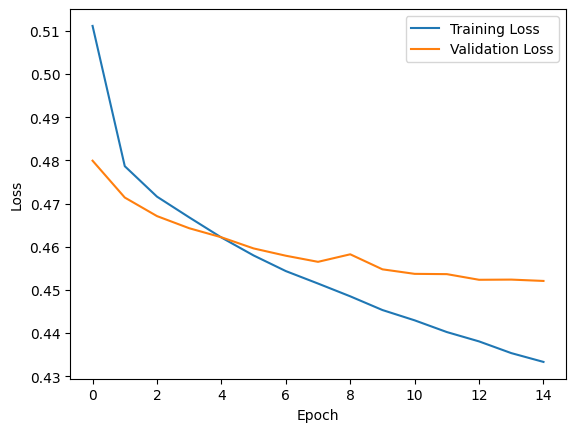


+--Evaluation Results--+
Loss: 0.45207940374153205
ROC AUC score: 0.8697841493558938
F1 score: 0.7839864195784411
Accuracy: 0.7838947070478347


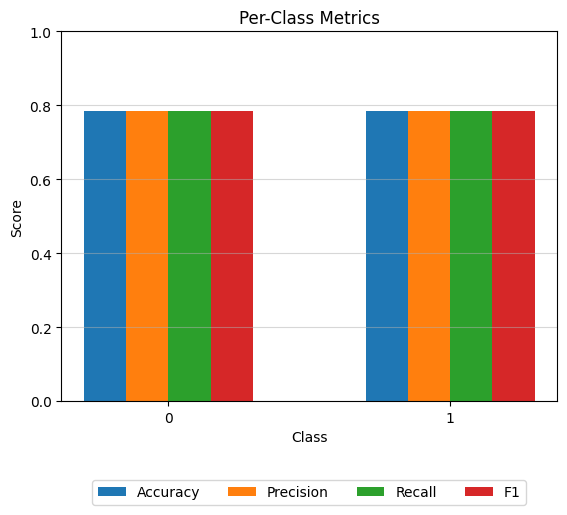

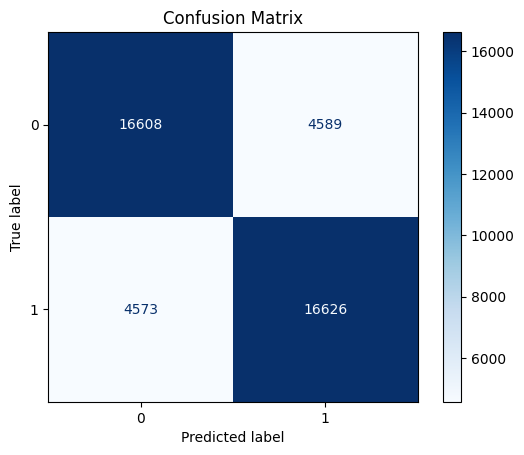

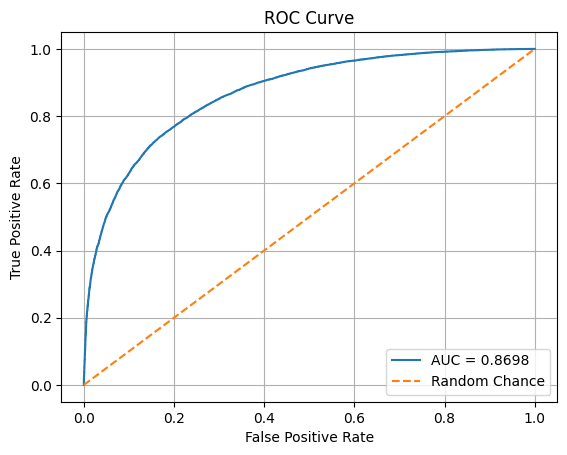

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


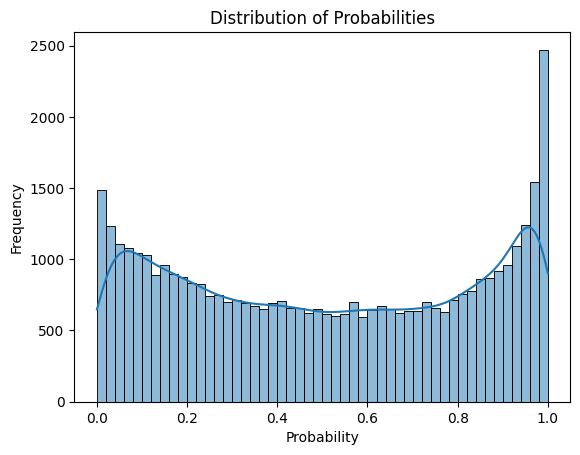

In [26]:
# Define layer sizes
set_seed(seed)
D_in = x_train.shape[1]
H = 256
D_out = 1

# Define Hyperparameters
learning_rate = 1e-3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_model = BaseNet(D_in, H, D_out).to(device)
criterion = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.Adam(base_model.parameters(), lr=learning_rate) 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6)
stopper = EarlyStopping()
epoch_num = 15

_ = train_function(base_model, optimizer, criterion, scheduler, stopper, train_dataloader, epoch_num, device)
_ = evaluation_function(base_model, criterion, val_dataloader, device)

### Optimization with Optuna

In [27]:
def suggest_model(trial):
    # Define the hyperparameters to be suggested
    optimizer_name = trial.suggest_categorical("optimizer_name", ["Adam", "AdamW"])
    learning_rate = trial.suggest_float("learning_rate", 1e-7, 1e-4, step=1e-7)
    scheduler_factor = trial.suggest_float("scheduler_factor", 0.3, 0.7, step=0.01)
    stopper_delta = trial.suggest_float("stopper_delta", 1e-6, 1e-4, step=1e-6)
    stopper_patience = trial.suggest_int("stopper_patience", 1, 6)
    dropout_factor = trial.suggest_float("dropout_factor", 0.15, 0.3, step=0.01)

    # Define input/output sizes
    D_in = x_train.shape[1]
    D_out = 1

    # Define model architecture
    model = nn.Sequential(
                nn.Linear(D_in, 768),
                nn.BatchNorm1d(768),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout_factor),
                nn.Linear(768, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout_factor),
                nn.Linear(256, D_out),
            ).to(device)
    
    # Initialise loss function, optimizer, scheduler and stopper
    criterion = nn.BCEWithLogitsLoss()
    
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=scheduler_factor, patience=2, min_lr=1e-7)
    stopper = EarlyStopping(patience=stopper_patience, delta=stopper_delta)

    return model, criterion, optimizer, scheduler, stopper

In [28]:
# Optuna architecture and hyperparameter tuning
def objective(trial):
    set_seed(seed)
    model, criterion, optimizer, scheduler, stopper = suggest_model(trial)
    epoch_num = 40
    current_loss = train_function(model, optimizer, criterion, scheduler, stopper, train_dataloader, epoch_num, device, print_flag=False, trial=trial)

    return current_loss

Because optuna's study is very time consuming the following code has been commented out and its results hard-coded into the model

In [29]:
# # Initialize pruner
# pruner = optuna.pruners.MedianPruner(n_startup_trials=25, n_warmup_steps=5, n_min_trials=40)

# # Call optuna to determine the best model
# study = optuna.create_study(sampler=optuna.samplers.TPESampler(multivariate=True),
#                             direction = 'minimize', 
#                             study_name = 'best-model', 
#                             pruner=pruner)
# study.optimize(objective, n_trials = 300)

# # Print results
# print('numbers of the finished trials:', len(study.trials))
# print('the best params:', study.best_trial.params)
# print('the best value:', study.best_value)

Optuna's results:
```{r, tidy=FALSE, eval=FALSE, highlight=FALSE }
numbers of the finished trials: 300
the best params: {'optimizer_name': 'AdamW', 'learning_rate': 7.329999999999999e-05, 'scheduler_factor': 0.32, 'stopper_delta': 4.599999999999999e-05, 'stopper_patience': 4, 'dropout_factor': 0.28}
the best value: 0.441486923540213
```

### Optimized Trial

Create a neural network based on optuna's results

In [30]:
class Net(nn.Module):
    def __init__(self, D_in, D_out):
        super(Net, self).__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(D_in, 768),
                nn.BatchNorm1d(768),
                nn.ReLU(inplace=True),
                nn.Dropout(0.28),
                nn.Linear(768, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(inplace=True),
                nn.Dropout(0.28),
                nn.Linear(256, D_out),
        )

    def forward(self, data):
        output = self.linear_stack(data)
        return output

Train and evaluate the model


+--Training--+
Using device: cuda
After epoch 0, the train loss is 0.5088275556934291 and the val loss is 0.46926260560032834
After epoch 5, the train loss is 0.45126873912482424 and the val loss is 0.4498914108577981
After epoch 10, the train loss is 0.4335889432193904 and the val loss is 0.4444140883454357
After epoch 15, the train loss is 0.4200256177063646 and the val loss is 0.443330386675984
After epoch 20, the train loss is 0.4077039792362986 and the val loss is 0.44186689399452095
After epoch 25, the train loss is 0.40511023332846574 and the val loss is 0.441510328776147
Stopping at epoch 25


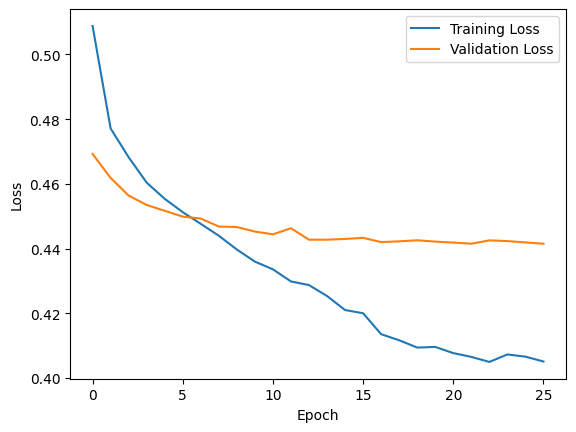


+--Evaluation Results--+
Loss: 0.441510328776147
ROC AUC score: 0.8761264015006854
F1 score: 0.7884284895932785
Accuracy: 0.7909236720445325


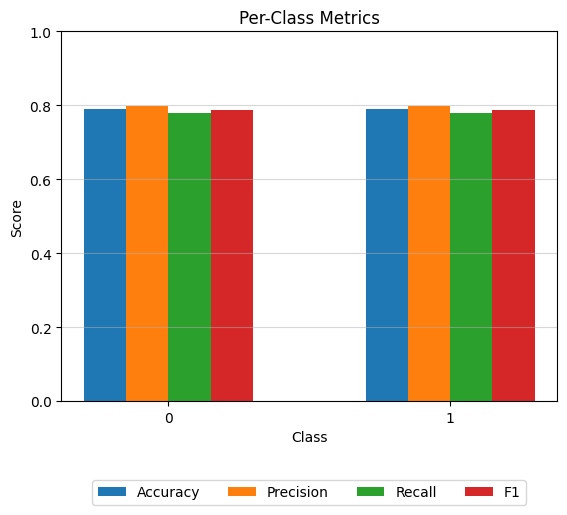

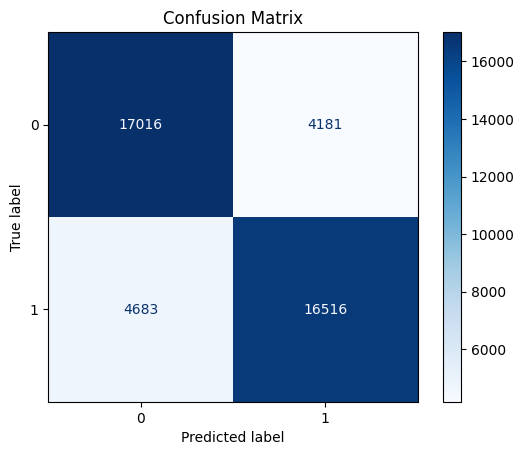

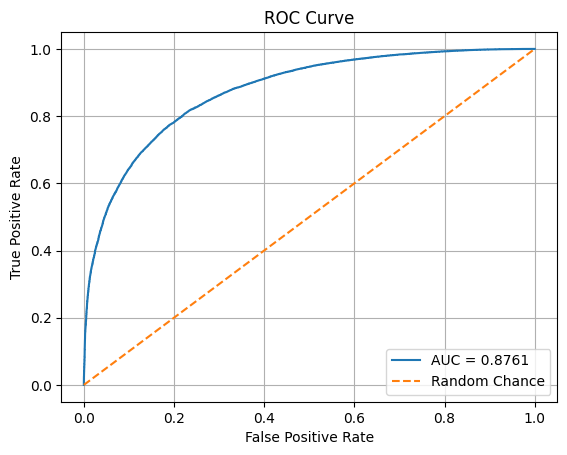

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


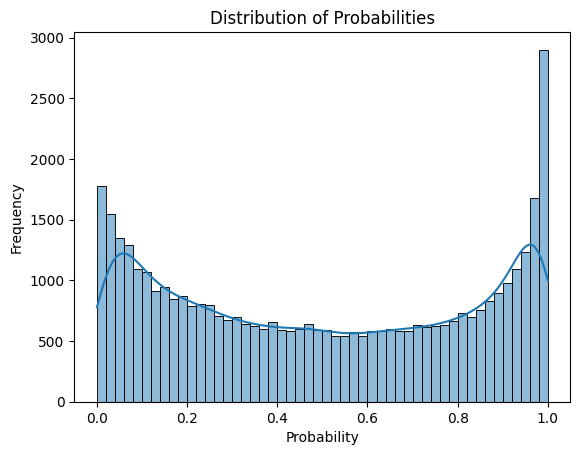

In [31]:
set_seed(seed)
epoch_num = 30
# Initialize the model, optimizer, scheduler, and stopper 
model = Net(D_in, D_out).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=7.329999999999999e-05)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.32, patience=2, min_lr=1e-7)
stopper = EarlyStopping(patience=4, delta=4.599999999999999e-05)

# Train and evaluate the model
train_function(model, optimizer, criterion, scheduler, stopper, train_dataloader, epoch_num, device)
_, true, predicted, probs  = evaluation_function(model, criterion, val_dataloader, device)

Run the training function multiple times to get a mean prediciton for each tweet

In [32]:
all_probs = []
epoch_num = 30

for i in range(10):
    set_seed(seed + i)  # Set a different seed for each run
    # Reinitialize the model, optimizer, scheduler, and stopper for each run
    model = Net(D_in, D_out).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=7.329999999999999e-05)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.32, patience=2, min_lr=1e-7)
    stopper = EarlyStopping(patience=4, delta=4.599999999999999e-05)

    # Train and evaluate the model
    train_function(model, optimizer, criterion, scheduler, stopper, train_dataloader, epoch_num, device, print_flag=False)
    _, true, _, probs  = evaluation_function(model, criterion, val_dataloader, device, print_flag=False)

    # Store predictions
    all_probs.append(probs)


+--Training--+
Using device: cuda
Stopping at epoch 25

+--Training--+
Using device: cuda
Stopping at epoch 22

+--Training--+
Using device: cuda
Stopping at epoch 22

+--Training--+
Using device: cuda
Stopping at epoch 23

+--Training--+
Using device: cuda
Stopping at epoch 22

+--Training--+
Using device: cuda
Stopping at epoch 27

+--Training--+
Using device: cuda
Stopping at epoch 26

+--Training--+
Using device: cuda
Stopping at epoch 26

+--Training--+
Using device: cuda
Stopping at epoch 21

+--Training--+
Using device: cuda
Stopping at epoch 23


ROC AUC score: 0.8796616381895994
F1 score: 0.7937026515151515
Accuracy: 0.7944617416737428


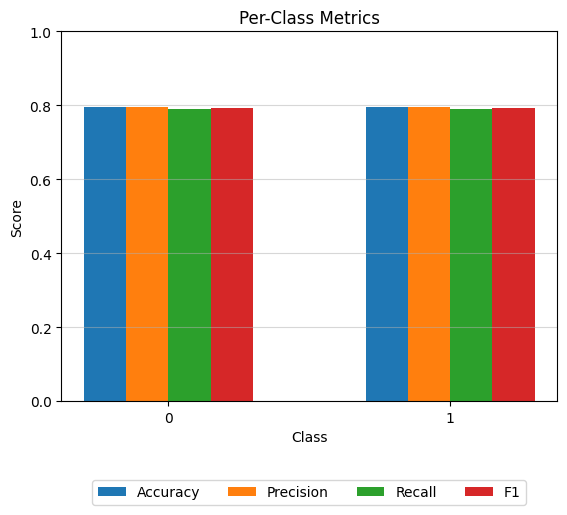

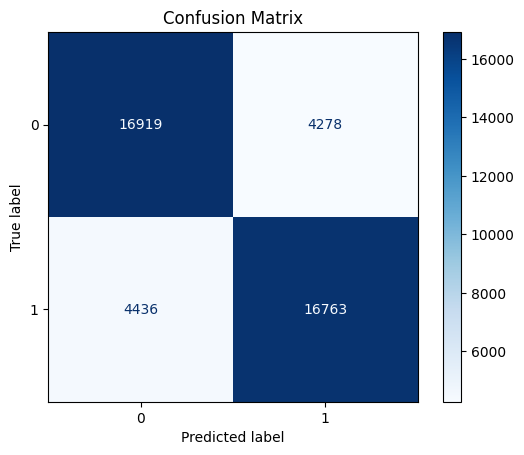

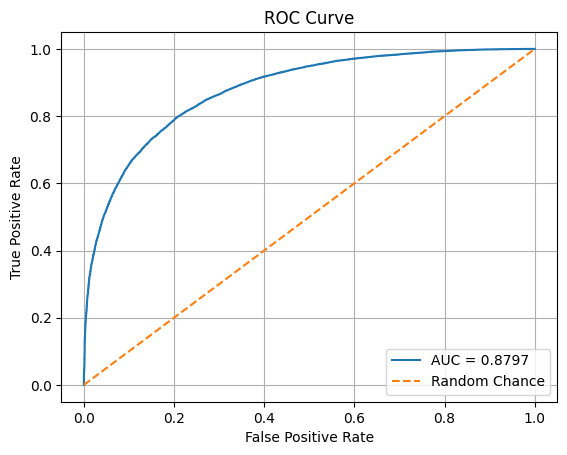

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


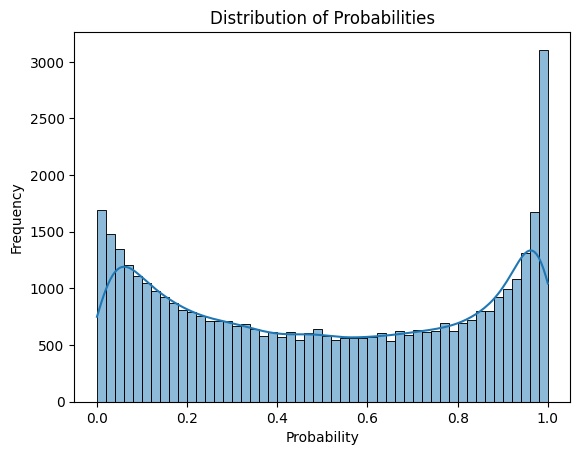

In [33]:
probs = np.stack(all_probs).mean(0).squeeze(-1)
mean_labels = np.round(np.stack(all_probs).mean(0).squeeze(-1)).astype(int)
print_plot_metrics(true, mean_labels, probs)

Use the test dataset to create the output submission

In [34]:
def inference(data, model):
    logits = torch.tensor([])
    logits = logits.to(device)

    mean_vectors = []

    for d in data['Text']:
        mv = w2v.get_mean_vector(d.split())
        mean_vectors.append(mv)

    x_test = torch.tensor(mean_vectors, dtype=torch.float)
    test_data = TensorDataset(x_test)
    test_dataloader = DataLoader(test_data, batch_size=128, shuffle=False)

    model.eval()
    with torch.no_grad():
        # Calculate the prediction for each item in the dataloader
        for (input,) in test_dataloader:
            input = input.to(device)
            output = model(input)
            logits = torch.cat((logits, output))

    # Convert tensors to numpy arrays
    probs = torch.sigmoid(logits)
    predicted = torch.round(probs).long().cpu().numpy()

    return predicted

In [35]:
test_prediction = inference(test_clean, model)

output = pd.DataFrame(data=test_clean['ID'])
output['Label'] = test_prediction
output.to_csv('submission.csv', index=False)

### Appendix

Load GloVe embeddings into a DataFrame and print them. Gives good insight into the pretrained vocabulary

In [36]:
# glove_df = pd.read_csv('glove.twitter.27B/glove.twitter.27B.200d.txt', sep=" ", quoting=3, header=None, index_col=0)
# glove_df.index.name = 'word'
# glove_df.reset_index(inplace=True)
# glove_df = glove_df[glove_df['word'].notna()]
# glove_df.dropna(inplace=True)
# glove_df[glove_df['word'].str.startswith('<')].word.to_numpy()

Used in print_plot_metrics function. More useful when data is not balanced

In [37]:
# PrecisionRecallDisplay.from_predictions(true.reshape(-1), predicted.reshape(-1))
# plt.title("Precision-Recall Curve")
# plt.show()

Lemmatization

In [38]:
# lemmatizer = WordNetLemmatizer()
# def lemmatize(text):
#     words = text.split()
#     lemmatized_words = [lemmatizer.lemmatize(w) for w in words]
#     return " ".join(lemmatized_words)

# train_clean['Text'] = train_clean['Text'].apply(lemmatize)
# val_clean['Text'] = val_clean['Text'].apply(lemmatize)
# test_clean['Text'] = test_clean['Text'].apply(lemmatize)